# Imtiaz Mahmud

# MileStone1 - NYC Yellow Taxi - March 1 - 3, 2023.</div>

In [1]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

import graphviz

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz

from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

%matplotlib inline

In [3]:
x = pd.read_csv("https://raw.githubusercontent.com/imtiaz-bronx/math-project/refs/heads/main/Files/YTM123.csv")
x

/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/3566360131.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  x = pd.read_csv("https://raw.githubusercontent.com/imtiaz-bronx/math-project/refs/heads/main/Files/YTM123.csv")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,03/01/2023 12:00:00 AM,03/01/2023 12:28:03 AM,1.0,12.77,1.0,N,138,87,1,51.30,6.00,0.5,5.00,6.55,1.0,74.10,2.5,1.25
1,2,03/01/2023 12:00:00 AM,03/01/2023 12:00:00 AM,3.0,6.22,1.0,N,162,13,2,29.60,0.00,0.5,0.00,0.00,1.0,33.60,2.5,0.00
2,2,03/01/2023 12:00:00 AM,03/01/2023 12:15:00 AM,NaN,3.83,NaN,NaN,68,238,0,18.14,0.00,0.5,4.43,0.00,1.0,26.57,NaN,NaN
3,2,03/01/2023 12:00:01 AM,03/01/2023 12:25:17 AM,1.0,13.93,1.0,N,132,155,1,54.10,1.00,0.5,11.32,0.00,1.0,69.17,0.0,1.25
4,2,03/01/2023 12:00:05 AM,03/01/2023 12:14:11 AM,2.0,2.9,1.0,N,234,13,1,16.30,1.00,0.5,3.00,0.00,1.0,24.30,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234239,1,03/02/2023 11:59:59 PM,03/03/2023 12:08:10 AM,1.0,1.0,1.0,N,79,113,1,7.90,3.50,0.5,1.00,0.00,1.0,13.90,2.5,0.00
234240,2,03/02/2023 11:59:59 PM,03/03/2023 12:27:50 AM,NaN,12.49,NaN,NaN,88,223,0,44.87,0.00,0.5,4.89,0.00,1.0,53.76,NaN,NaN
234241,1,03/03/2023 12:00:00 AM,03/03/2023 12:24:02 AM,1.0,8.4,1.0,N,138,24,1,35.90,7.25,0.5,5.00,6.55,1.0,56.20,0.0,1.25
234242,2,03/03/2023 12:00:00 AM,03/03/2023 12:04:39 AM,2.0,0.56,1.0,N,114,158,1,5.80,1.00,0.5,2.16,0.00,1.0,12.96,2.5,0.00


### About the Date:

In [4]:
x.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance             object
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
airport_fee              float64
dtype: object

In [5]:
x.tail(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
234239,1,03/02/2023 11:59:59 PM,03/03/2023 12:08:10 AM,1.0,1.0,1.0,N,79,113,1,7.90,3.50,0.5,1.00,0.00,1.0,13.90,2.5,0.00
234240,2,03/02/2023 11:59:59 PM,03/03/2023 12:27:50 AM,NaN,12.49,NaN,NaN,88,223,0,44.87,0.00,0.5,4.89,0.00,1.0,53.76,NaN,NaN
234241,1,03/03/2023 12:00:00 AM,03/03/2023 12:24:02 AM,1.0,8.4,1.0,N,138,24,1,35.90,7.25,0.5,5.00,6.55,1.0,56.20,0.0,1.25
234242,2,03/03/2023 12:00:00 AM,03/03/2023 12:04:39 AM,2.0,0.56,1.0,N,114,158,1,5.80,1.00,0.5,2.16,0.00,1.0,12.96,2.5,0.00
234243,2,03/03/2023 12:00:00 AM,03/03/2023 12:22:00 AM,NaN,5.71,NaN,NaN,79,238,0,24.47,0.00,0.5,5.69,0.00,1.0,34.16,NaN,NaN


In [6]:
x['tpep_pickup_datetime'] = pd.to_datetime(x['tpep_pickup_datetime'])
x['tpep_dropoff_datetime'] = pd.to_datetime(x['tpep_dropoff_datetime'])
x.dtypes

/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/4005381308.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  x['tpep_pickup_datetime'] = pd.to_datetime(x['tpep_pickup_datetime'])
/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/4005381308.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  x['tpep_dropoff_datetime'] = pd.to_datetime(x['tpep_dropoff_datetime'])


VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                    object
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

In [7]:
dup_filter = x.duplicated()
x[dup_filter]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [8]:
x.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,234244.000000,234244,234244,228205.000000,228205.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,234244.000000,228205.000000,228205.000000
mean,1.721282,2023-03-02 03:25:51.752873472,2023-03-02 03:42:37.366225152,1.295287,1.662667,167.495748,165.808588,1.172786,18.538090,1.763517,0.488725,3.497108,0.518409,0.982311,27.522062,2.287340,0.096010
min,1.000000,2023-03-01 00:00:00,2023-03-01 00:00:00,0.000000,1.000000,1.000000,1.000000,0.000000,-229.800000,-7.500000,-0.500000,-2.170000,-27.850000,-1.000000,-252.850000,-2.500000,-1.250000
25%,1.000000,2023-03-01 15:50:12,2023-03-01 16:08:30,1.000000,1.000000,132.000000,125.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,16.000000,2.500000,0.000000
50%,2.000000,2023-03-02 00:51:50,2023-03-02 01:08:28.500000,1.000000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.900000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-03-02 16:03:22,2023-03-02 16:22:09.249999872,1.000000,1.000000,234.000000,234.000000,1.000000,20.500000,2.500000,0.500000,4.340000,0.000000,1.000000,29.400000,2.500000,0.000000
max,6.000000,2023-03-03 00:00:00,2023-03-03 23:19:44,6.000000,99.000000,265.000000,265.000000,4.000000,446.100000,11.250000,4.000000,237.150000,177.000000,1.000000,482.450000,2.500000,1.250000
std,0.461507,NaN,NaN,0.849248,7.671498,62.661207,68.657427,0.516893,17.241348,1.867576,0.097627,3.818645,2.044371,0.182196,21.664501,0.754667,0.337354


In [9]:
missing_rows = x.isna().any(axis = 1)
missing_rows.head()

0    False
1    False
2     True
3    False
4    False
dtype: bool

In [10]:
missing_rows.sum()

np.int64(6039)

In [11]:
ax =x[~missing_rows]
ax.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-03-01 00:00:00,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,51.3,6.0,0.5,5.00,6.55,1.0,74.10,2.5,1.25
1,2,2023-03-01 00:00:00,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,29.6,0.0,0.5,0.00,0.00,1.0,33.60,2.5,0.00
3,2,2023-03-01 00:00:01,2023-03-01 00:25:17,1.0,13.93,1.0,N,132,155,1,54.1,1.0,0.5,11.32,0.00,1.0,69.17,0.0,1.25
4,2,2023-03-01 00:00:05,2023-03-01 00:14:11,2.0,2.9,1.0,N,234,13,1,16.3,1.0,0.5,3.00,0.00,1.0,24.30,2.5,0.00
5,2,2023-03-01 00:00:06,2023-03-01 00:12:05,1.0,2.95,1.0,N,158,163,1,15.6,1.0,0.5,4.12,0.00,1.0,24.72,2.5,0.00


In [12]:
len(ax)

228205

In [13]:
len(x)

234244

In [14]:
234244 - 228205

6039

In [15]:
abc = ax["total_amount"] >= 0
abc.value_counts()

total_amount
True     226322
False      1883
Name: count, dtype: int64

# No Duplicated Data Found...only 6039 missing rows removed. The clean data has 228205 rows....

In [16]:
abc.head(5)

0    True
1    True
3    True
4    True
5    True
Name: total_amount, dtype: bool

Text(0, 0.5, 'Number of Rides')

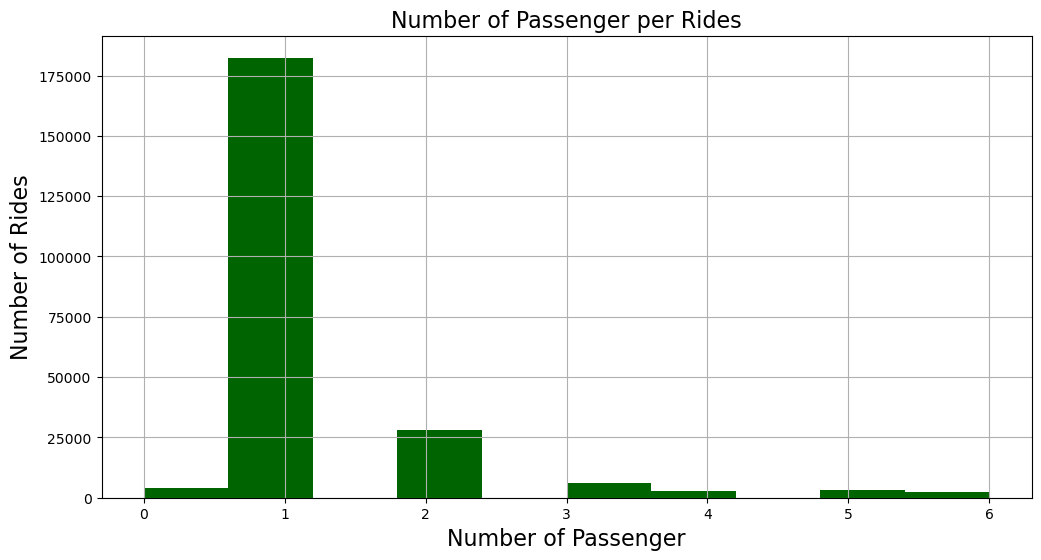

In [17]:
plt.figure(figsize=(12, 6))
ax["passenger_count"].hist(color = "darkgreen",)
plt.title("Number of Passenger per Rides",fontsize=16)
plt.xlabel("Number of Passenger", fontsize=16)
plt.ylabel("Number of Rides", fontsize=16)

In [18]:
ax.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-03-01 00:00:00,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,51.3,6.0,0.5,5.00,6.55,1.0,74.10,2.5,1.25
1,2,2023-03-01 00:00:00,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,29.6,0.0,0.5,0.00,0.00,1.0,33.60,2.5,0.00
3,2,2023-03-01 00:00:01,2023-03-01 00:25:17,1.0,13.93,1.0,N,132,155,1,54.1,1.0,0.5,11.32,0.00,1.0,69.17,0.0,1.25
4,2,2023-03-01 00:00:05,2023-03-01 00:14:11,2.0,2.9,1.0,N,234,13,1,16.3,1.0,0.5,3.00,0.00,1.0,24.30,2.5,0.00
5,2,2023-03-01 00:00:06,2023-03-01 00:12:05,1.0,2.95,1.0,N,158,163,1,15.6,1.0,0.5,4.12,0.00,1.0,24.72,2.5,0.00


In [19]:
ax[["trip_distance", "tip_amount"]].dtypes

trip_distance     object
tip_amount       float64
dtype: object

In [20]:
ax["trip_distance"] = ax["trip_distance"].str.replace(",","")

ax["trip_distance"] = ax["trip_distance"].astype(float)


/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/3775958405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ax["trip_distance"] = ax["trip_distance"].str.replace(",","")
/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/3775958405.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ax["trip_distance"] = ax["trip_distance"].astype(float)


In [21]:
ax[["trip_distance", "tip_amount"]].dtypes

trip_distance    float64
tip_amount       float64
dtype: object

In [22]:
ax["tpep_pickup_datetime"] = pd.to_datetime(ax["tpep_pickup_datetime"])

/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/1733982461.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ax["tpep_pickup_datetime"] = pd.to_datetime(ax["tpep_pickup_datetime"])


In [23]:
def maxx(x):
    if x > 0:
        return 1
    else:
        return 0

In [24]:
ax["toll_x"] = ax["tolls_amount"].apply(maxx)

/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/2136712501.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ax["toll_x"] = ax["tolls_amount"].apply(maxx)


Text(0, 0.5, 'Number of Trips')

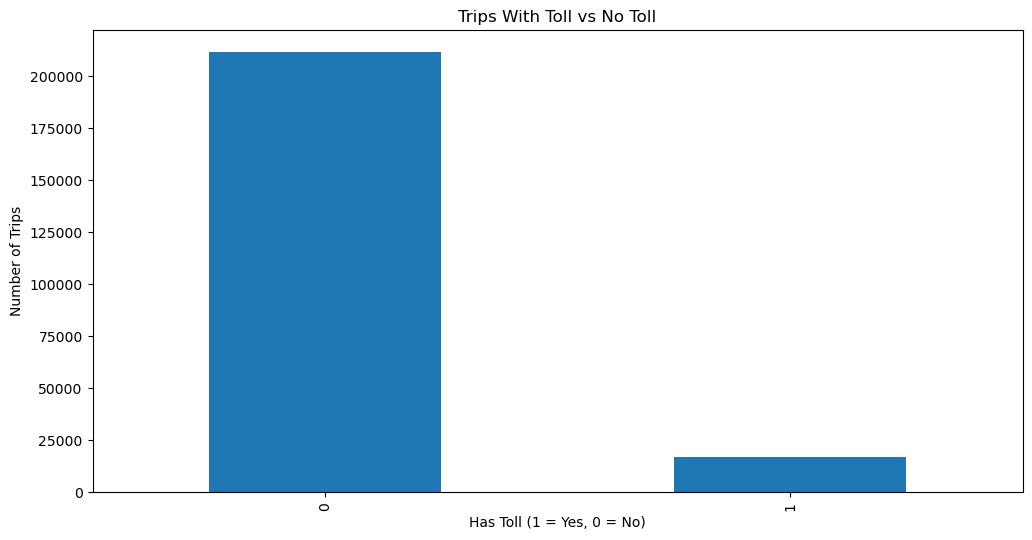

In [25]:
plt.figure(figsize=(12, 6))

tx = ax["toll_x"].value_counts()

tx.plot(kind="bar")

plt.title("Trips With Toll vs No Toll")
plt.xlabel("Has Toll (1 = Yes, 0 = No)")
plt.ylabel("Number of Trips")


In [26]:
ax.head(1)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,toll_x
0,2,2023-03-01,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,51.3,6.0,0.5,5.0,6.55,1.0,74.1,2.5,1.25,1


In [27]:
def rrr(x):
    if x > 0:
        return 1
    else:
        return 0

In [28]:
ax["c_x"] =ax["congestion_surcharge"].apply(rrr)

/var/folders/kh/6dm4qzbx2715lv20ty5zgyzw0000gn/T/ipykernel_18261/1868709301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ax["c_x"] =ax["congestion_surcharge"].apply(rrr)


Text(0.5, 0, 'Number of Rides')

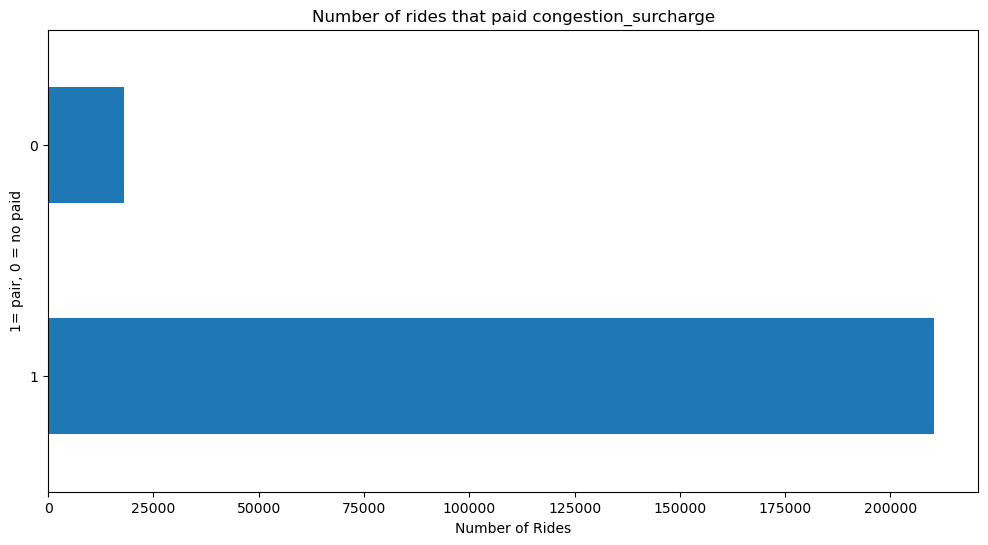

In [29]:
plt.figure(figsize=(12, 6))

yellow = ax["c_x"].value_counts()
yellow.plot(kind = "barh")
plt.title("Number of rides that paid congestion_surcharge")
plt.ylabel("1= pair, 0 = no paid")
plt.xlabel("Number of Rides")

Text(0.5, 0, 'Type of Paynment')

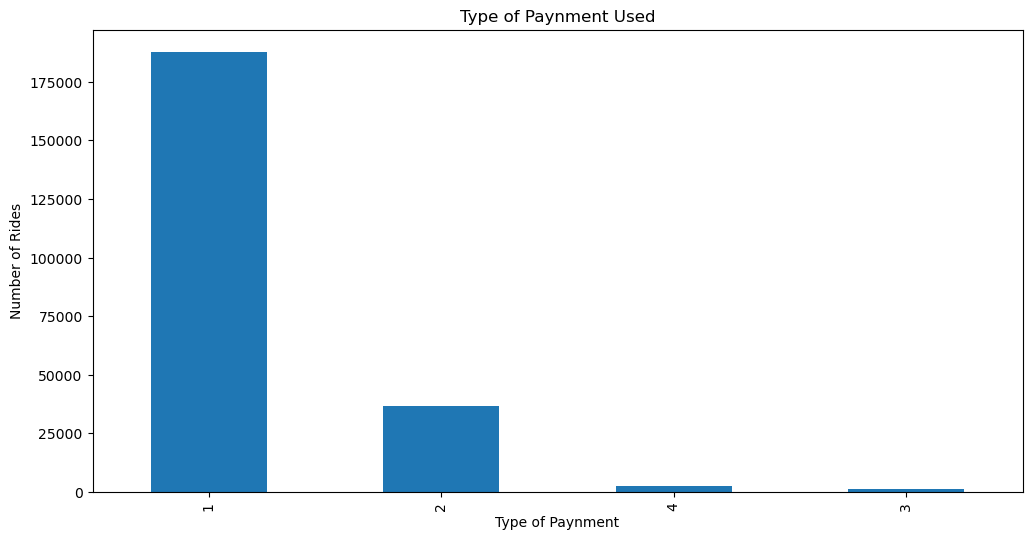

In [30]:
plt.figure(figsize=(12, 6))

pymn = ax["payment_type"].value_counts()
pymn.plot(kind = "bar")
plt.title("Type of Paynment Used")
plt.ylabel("Number of Rides")
plt.xlabel("Type of Paynment")

Text(0, 0.5, 'Average Total Amount ($)')

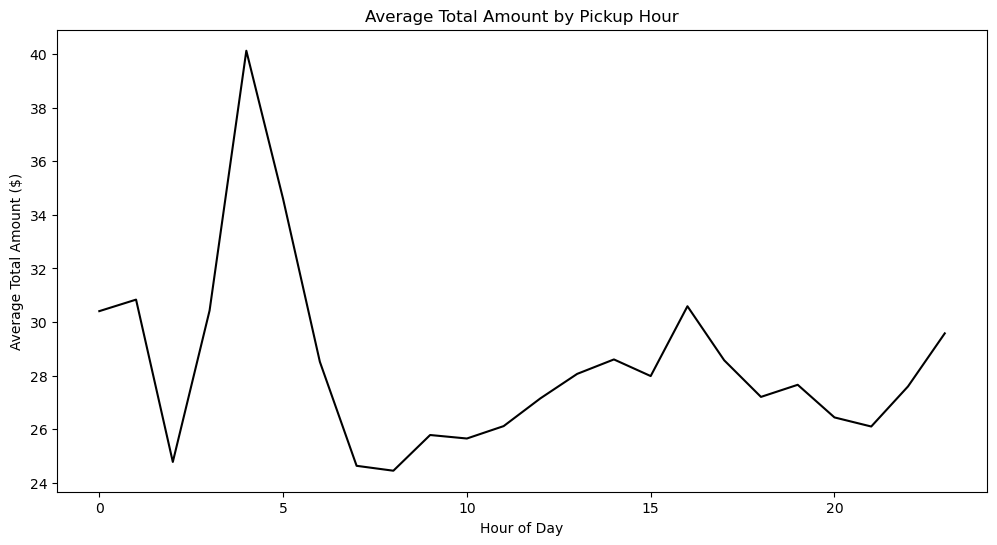

In [31]:
plt.figure(figsize=(12, 6))


aaa = ax.groupby(ax["tpep_pickup_datetime"].dt.hour)["total_amount"].mean()
aaa.plot(kind="line", color = "black")
plt.title("Average Total Amount by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Amount ($)")

In [32]:
ax.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,toll_x,c_x
0,2,2023-03-01,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,...,6.0,0.5,5.0,6.55,1.0,74.1,2.5,1.25,1,1
1,2,2023-03-01,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,...,0.0,0.5,0.0,0.00,1.0,33.6,2.5,0.00,0,1


Text(0, 0.5, 'Average Total Tip Amount ($)')

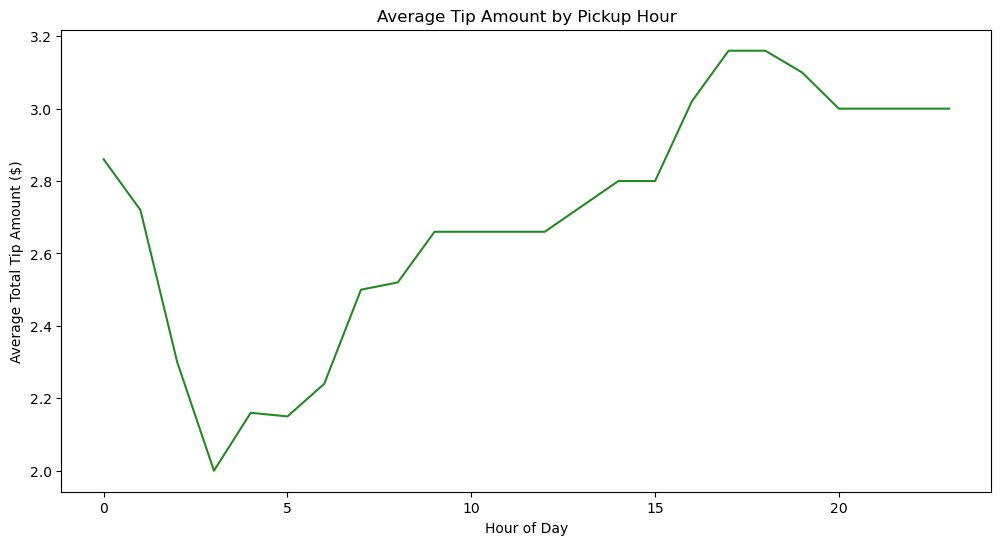

In [33]:
plt.figure(figsize=(12, 6))


aaa = ax.groupby(ax["tpep_pickup_datetime"].dt.hour)["tip_amount"].median()
aaa.plot(kind="line", color = "forestgreen")
plt.title("Average Tip Amount by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Tip Amount ($)")

Text(0, 0.5, 'Average Total Amount ($)')

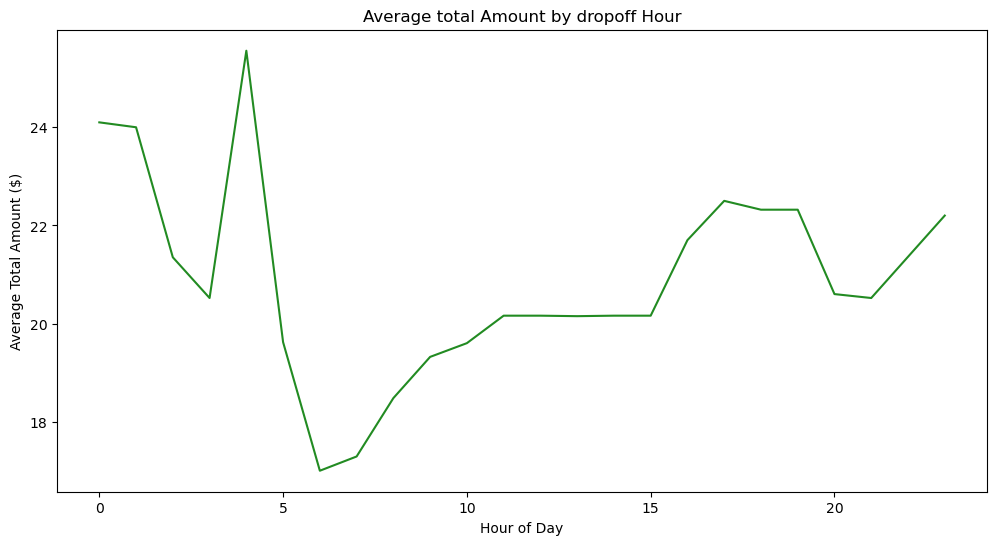

In [34]:
plt.figure(figsize=(12, 6))


aaa = ax.groupby(ax["tpep_dropoff_datetime"].dt.hour)["total_amount"].median()
aaa.plot(kind="line", color = "forestgreen")
plt.title("Average total Amount by dropoff Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Amount ($)")

In [35]:
ax

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,toll_x,c_x
0,2,2023-03-01 00:00:00,2023-03-01 00:28:03,1.0,12.77,1.0,N,138,87,1,...,6.00,0.5,5.00,6.55,1.0,74.10,2.5,1.25,1,1
1,2,2023-03-01 00:00:00,2023-03-01 00:00:00,3.0,6.22,1.0,N,162,13,2,...,0.00,0.5,0.00,0.00,1.0,33.60,2.5,0.00,0,1
3,2,2023-03-01 00:00:01,2023-03-01 00:25:17,1.0,13.93,1.0,N,132,155,1,...,1.00,0.5,11.32,0.00,1.0,69.17,0.0,1.25,0,0
4,2,2023-03-01 00:00:05,2023-03-01 00:14:11,2.0,2.90,1.0,N,234,13,1,...,1.00,0.5,3.00,0.00,1.0,24.30,2.5,0.00,0,1
5,2,2023-03-01 00:00:06,2023-03-01 00:12:05,1.0,2.95,1.0,N,158,163,1,...,1.00,0.5,4.12,0.00,1.0,24.72,2.5,0.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234237,2,2023-03-02 23:59:57,2023-03-03 00:10:04,2.0,NaN,1.0,N,142,140,1,...,1.00,0.5,3.00,0.00,1.0,20.10,2.5,0.00,0,1
234238,2,2023-03-02 23:59:57,2023-03-03 00:22:30,3.0,NaN,1.0,N,230,162,1,...,1.00,0.5,0.00,0.00,1.0,24.80,2.5,0.00,0,1
234239,1,2023-03-02 23:59:59,2023-03-03 00:08:10,1.0,NaN,1.0,N,79,113,1,...,3.50,0.5,1.00,0.00,1.0,13.90,2.5,0.00,0,1
234241,1,2023-03-03 00:00:00,2023-03-03 00:24:02,1.0,NaN,1.0,N,138,24,1,...,7.25,0.5,5.00,6.55,1.0,56.20,0.0,1.25,1,0


In [36]:
ax.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'toll_x', 'c_x'],
      dtype='object')

In [37]:
data2 = ax[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'tip_amount', 'tolls_amount', 'total_amount']]
display(data2.head())

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,tip_amount,tolls_amount,total_amount
0,2023-03-01 00:00:00,2023-03-01 00:28:03,1.0,12.77,5.00,6.55,74.10
1,2023-03-01 00:00:00,2023-03-01 00:00:00,3.0,6.22,0.00,0.00,33.60
3,2023-03-01 00:00:01,2023-03-01 00:25:17,1.0,13.93,11.32,0.00,69.17
4,2023-03-01 00:00:05,2023-03-01 00:14:11,2.0,2.90,3.00,0.00,24.30
5,2023-03-01 00:00:06,2023-03-01 00:12:05,1.0,2.95,4.12,0.00,24.72


# Step 8

In [38]:
data2.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'tip_amount', 'tolls_amount', 'total_amount'],
      dtype='object')

In [39]:
data2 = data2[data2['trip_distance'] < 150]
data2 = data2[data2['total_amount'] > 0]

In [40]:
data2 = data2[data2['trip_distance'] > 0.1]
data2 = data2[(data2['passenger_count'] > 0) & (data2['passenger_count'] <= 6)]

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
data2 = data2.dropna()

In [43]:
X = data2[['trip_distance', 'passenger_count']]
y = data2['total_amount']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred = model.predict(X_test)

In [47]:
print("Model 1 Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Model 1 Results:
MSE: 55.34662272533217
R2: 0.8843708342154871


In [48]:
model1 = smf.ols(formula='total_amount ~ trip_distance + passenger_count', data=data2).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           total_amount   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                 6.317e+05
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        11:36:44   Log-Likelihood:            -5.1800e+05
No. Observations:              152849   AIC:                         1.036e+06
Df Residuals:                  152846   BIC:                         1.036e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.1630      0.036    335.226      0.000      12.092      12.234
trip_distance       4.6818      0.004   1122.837      0.000       4.674       4.690
passenger_count     0.0522      0.022      2.393      0.017       0.009       0.095
==============================================================================
Omnibus:                   156704.512   Durbin-Watson:                   1.895
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        114197284.443
Skew:                           4.242   Prob(JB):                         0.00
Kurtosis:                     136.638   Cond. No.                         12.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Step 8..Model 2

In [49]:
X = data2[['trip_distance', 'passenger_count', 'tip_amount', 'tolls_amount']]
y = data2['total_amount']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [51]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
y_pred = model.predict(X_test)

In [53]:
print("Step 8, Model 2 Results,L.G.:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Step 8, Model 2 Results,L.G.:
MSE: 33.1110223952662
R2: 0.9326678091032298


In [54]:
model2 = smf.ols(formula='total_amount ~ trip_distance + passenger_count + tip_amount + tolls_amount', data=data2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           total_amount   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 6.576e+05
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        11:36:44   Log-Likelihood:            -4.6637e+05
No. Observations:              152849   AIC:                         9.328e+05
Df Residuals:                  152844   BIC:                         9.328e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.3868      0.028    376.648      0.000      10.333      10.441
trip_distance       3.5449      0.004    811.707      0.000       3.536       3.553
passenger_count     0.0980      0.016      6.302      0.000       0.068       0.129
tip_amount          1.3636      0.004    318.861      0.000       1.355       1.372
tolls_amount        1.2929      0.008    157.629      0.000       1.277       1.309
==============================================================================
Omnibus:                   244575.076   Durbin-Watson:                   1.876
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       1303345501.398
Skew:                           9.616   Prob(JB):                         0.00
Kurtosis:                     454.972   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

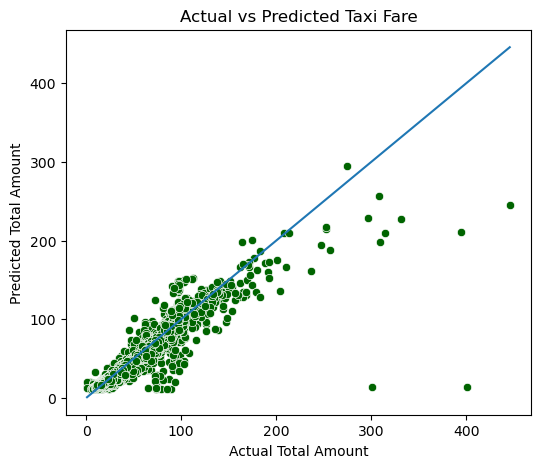

In [55]:
plt.figure(figsize=(6, 5))

sns.scatterplot(x=y_test, y=y_pred, color = "darkgreen")
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Actual vs Predicted Taxi Fare")

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])

Text(0.5, 1.0, 'Trip Distance vs Total Fare')

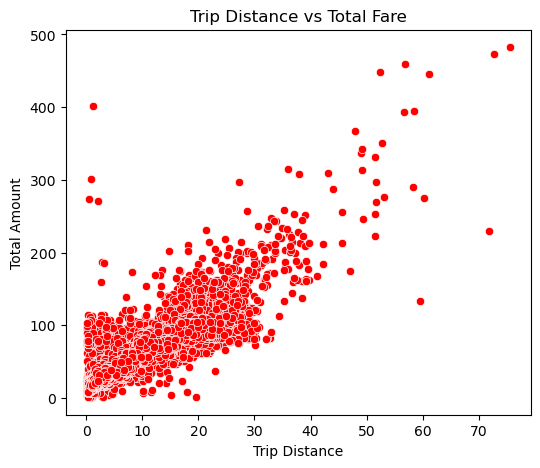

In [56]:

plt.figure(figsize=(6,5))
sns.scatterplot(x="trip_distance", y="total_amount", data=data2, color = "red")

plt.xlabel("Trip Distance")
plt.ylabel("Total Amount")
plt.title("Trip Distance vs Total Fare")

#Step 9

In [57]:
from sklearn.neighbors import KNeighborsRegressor

In [58]:
X = data2[['trip_distance', 'passenger_count', 'tip_amount', 'tolls_amount']]
y = data2['total_amount']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [60]:
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
y_pred_knn = model_knn.predict(X_test)

print("KNN Model Results:")
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R2:", r2_score(y_test, y_pred_knn))

KNN Model Results:
MSE: 15.08443826365718
R2: 0.9676172830963565


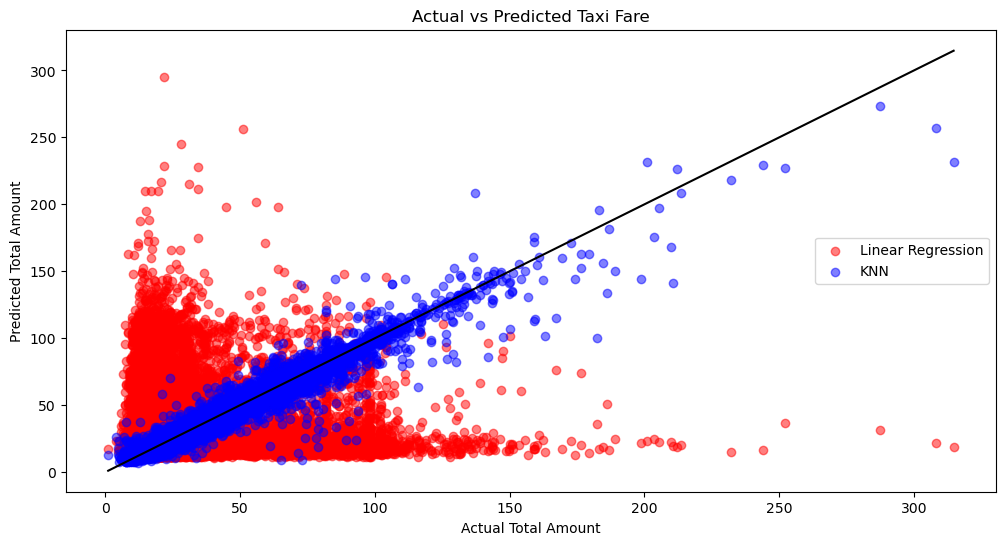

In [62]:
plt.figure(figsize=(12, 6))

plt.scatter(y_test, y_pred, label="Linear Regression", color = "red", alpha=0.5)
plt.scatter(y_test, y_pred_knn, label="KNN", color = "blue", alpha=0.5)
plt.legend()

plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Actual vs Predicted Taxi Fare")

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],color='black')


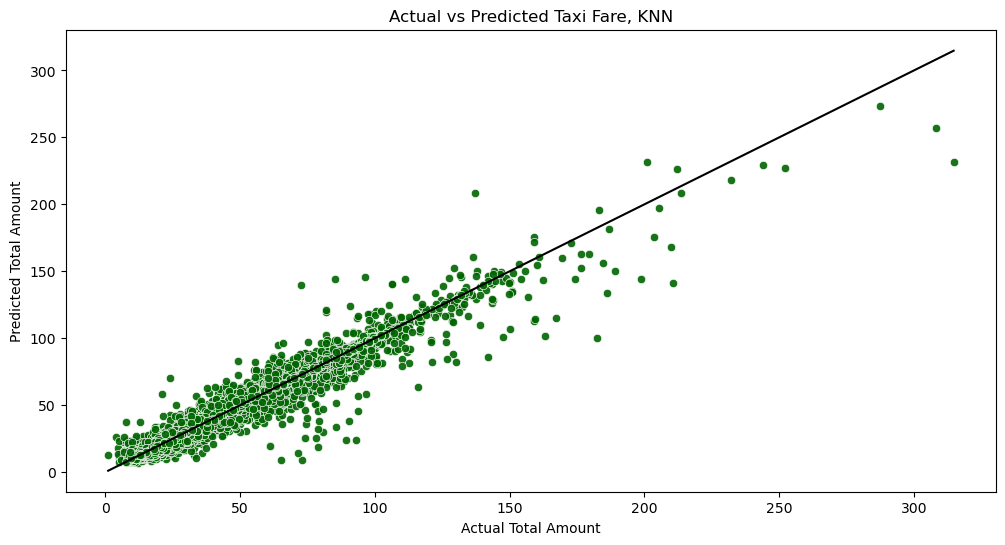

In [63]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x = y_test, y = y_pred_knn, color = "darkgreen", alpha=0.9)

plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Actual vs Predicted Taxi Fare, KNN")

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],color='black')


In [64]:
data2.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'tip_amount', 'tolls_amount', 'total_amount'],
      dtype='object')

In [73]:
corr = data2[['trip_distance',
              'tip_amount',
              'tolls_amount',
              'passenger_count',
              'total_amount']].corr()

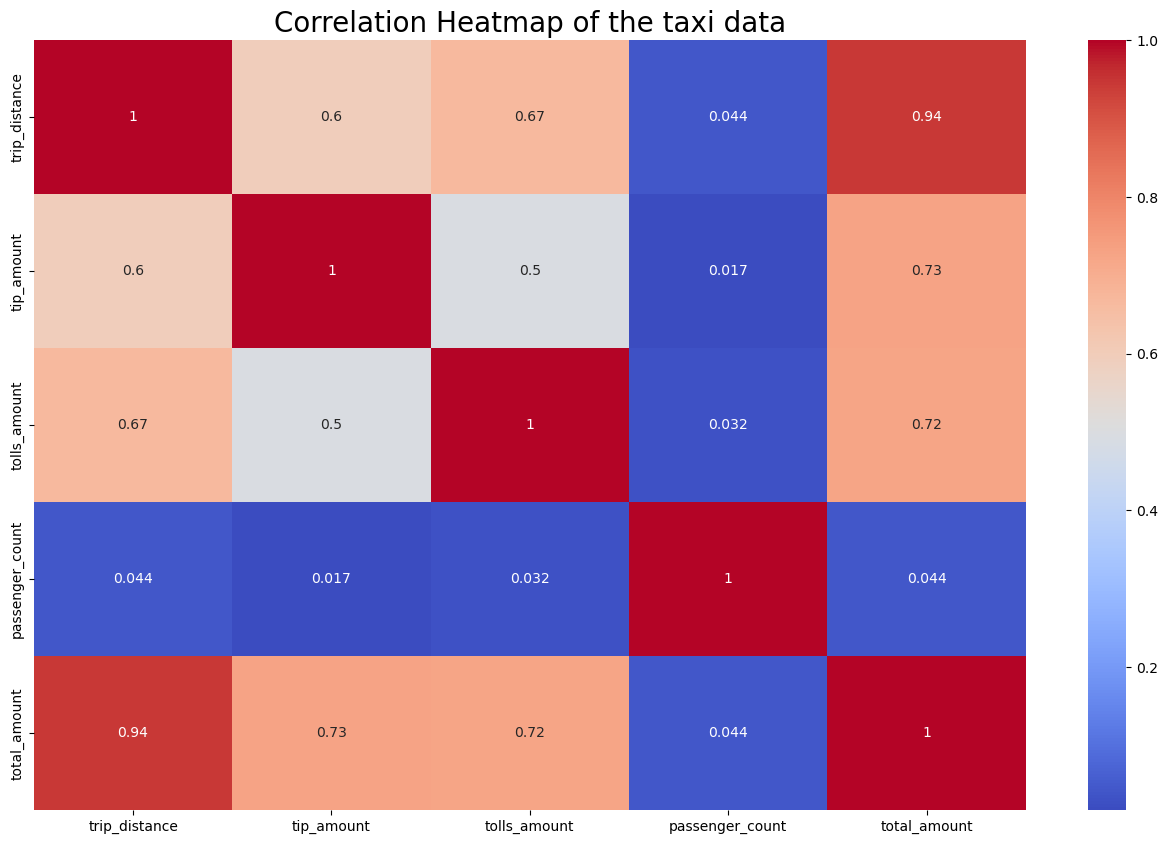

In [81]:
plt.figure(figsize = (16,10))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap of the taxi data", fontsize = 20)
plt.savefig("heatmap.png", dpi = 350)

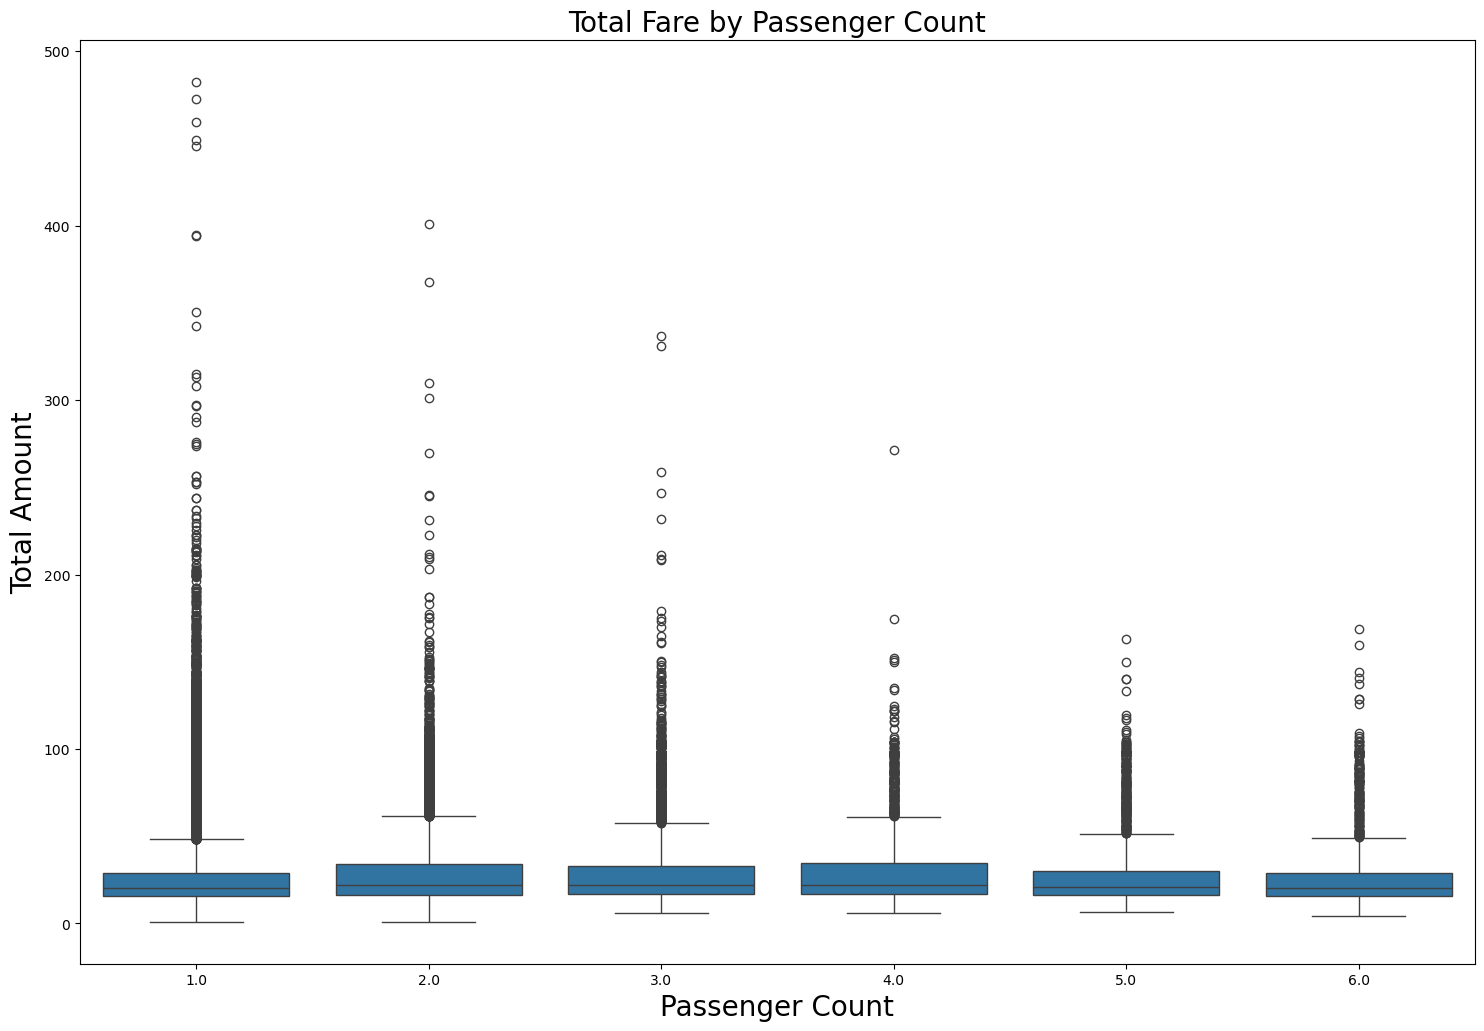

In [84]:
plt.figure(figsize=(18,12))

sns.boxplot(x='passenger_count',y='total_amount',data=data2)

plt.title("Total Fare by Passenger Count", fontsize = 20)
plt.xlabel("Passenger Count", fontsize = 20)
plt.ylabel("Total Amount", fontsize = 20)
plt.savefig("boxmap.png", dpi = 300)